In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

In [ ]:
def filter_and_group_stocks(file_path):
    """
    Filters stocks listed on NYSE (EXCHCD = 1) and AMEX (EXCHCD = 2),
    and groups the time series of price (PRC), volume (VOL), and return (RET) by PERMNO.

    Parameters:
        file_path (str): Path to the CSV file containing the stock data.

    Returns:
        dict: A dictionary where keys are PERMNOs and values are DataFrames
              containing the time series of PRC, VOL, and RET for each stock.
    """
    # Load the CSV file into a pandas DataFrame
    data = pd.read_csv(file_path)
    
    # Filter for NYSE (EXCHCD = 1) and AMEX (EXCHCD = 2)
    filtered_data = data[(data['EXCHCD'] == 1) | (data['EXCHCD'] == 2)]
    
    # Group by PERMNO and extract time series for PRC, VOL, and RET
    grouped_data = {}
    MC_record_first = np.zeros(120)
    MC_record_last = np.zeros(120)
    for permno, group in filtered_data.groupby('PERMNO'):
        # Sort by date to ensure the time series is in order
        group = group.sort_values(by='date')
        
        # Keep only relevant columns
        sub_data = group[['date', 'PRC', 'VOL', 'RET', 'SHROUT']].reset_index(drop=True)

        sub_data = sub_data.dropna()

        sub_data.loc[:, 'RET'] = pd.to_numeric(sub_data['RET'], errors='coerce')
        sub_data.loc[:, 'VOL'] = pd.to_numeric(sub_data['VOL'], errors='coerce')
        sub_data.loc[:, 'PRC'] = pd.to_numeric(sub_data['PRC'], errors='coerce')
        sub_data.loc[:, 'SHROUT'] = pd.to_numeric(sub_data['SHROUT'], errors='coerce')

        sub_data = sub_data.dropna()
        sub_data = sub_data.reset_index(drop=True)

        # Ensure the 'date' column is in datetime format
        sub_data['date'] = pd.to_datetime(sub_data['date'])

        # Slice the DataFrame to only include rows from 2019-01-01 to 2018-12-31
        sub_data = sub_data[(sub_data['date'] >= '2009-01-01') & (sub_data['date'] <= '2018-12-31')]

        # Extract year-month and identify the beginning-of-month price
        sub_data['year_month'] = sub_data['date'].dt.to_period('M')

        # Get the beginning-of-month price
        beginning_of_month = sub_data.groupby(['year_month']).first().reset_index(drop=True)
        monthly_counts = sub_data.groupby('year_month').size().reset_index(name='row_count')
        bool_1 = np.array(monthly_counts['row_count'] > 15)
        # monthly_counts['greater_than_15'] = monthly_counts['row_count'] > 15

        beginning_of_month = beginning_of_month.rename(columns={'PRC': 'BOM_PRC'})  # Rename for clarity

        # Add a condition column: True if BOM_PRC between $5 and $1000 and valid days >= 15
        bool_2 = np.array((beginning_of_month['BOM_PRC'] >= 5) & (beginning_of_month['BOM_PRC'] <= 1000))
        # beginning_of_month['meets_conditions'] = (beginning_of_month['BOM_PRC'] >= 5) & (beginning_of_month['BOM_PRC'] <= 1000)
        bool_arr = bool_1 & bool_2
        if np.sum(bool_arr) == len(bool_arr) and len(sub_data)>=2516:
            sub_data = sub_data.set_index('date')
            sub_data['Market_Cap'] = sub_data['PRC'] * (sub_data['SHROUT']*1000)
            # Use resample to get the last entry of each month
            last_day_prices = sub_data.resample('M').last()['Market_Cap']
            first_day_prices = sub_data.resample('M').first()['Market_Cap']

            # Reset the index to make it a regular DataFrame
            last_day_prices = last_day_prices.reset_index()
            first_day_prices = first_day_prices.reset_index()

            # Rename columns for clarity
            last_day_prices.columns = ['date', 'Market_Cap']
            first_day_prices.columns = ['date', 'Market_Cap']

            MC_arr_last = np.array(last_day_prices['Market_Cap'])
            MC_record_last = MC_record_last + MC_arr_last
            MC_arr_first = np.array(first_day_prices['Market_Cap'])
            MC_record_first = MC_record_first + MC_arr_first
            # Store the time series in a dictionary
            grouped_data[permno] = sub_data

    return grouped_data, MC_record_first, MC_record_last

In [ ]:
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
warnings.simplefilter(action='ignore', category=pd.errors.DtypeWarning)

In [ ]:
file_path = 'data_10y_new.csv'

In [ ]:
stock_groups, MC_record_first, MC_record_last = filter_and_group_stocks(file_path)

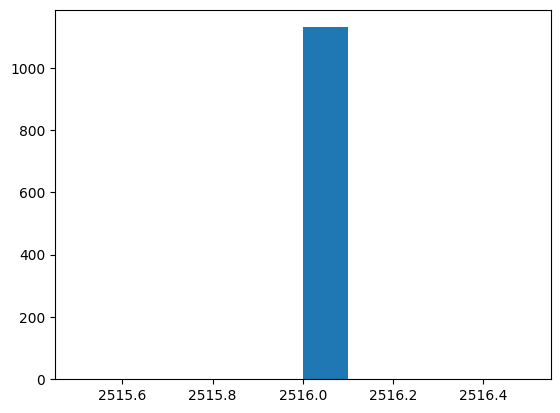

In [ ]:
key_list = list(stock_groups.keys())
length_list = []
for key in key_list:
    df_tmp = stock_groups[key]
    length_list.append(len(df_tmp))

plt.hist(length_list)
q_90 = np.quantile(length_list, 0.90)

In [ ]:
def compute_features(key):
    # Assuming the dataset is already loaded into a DataFrame called `data`
    data = stock_groups[key]  # Replace with your DataFrame

    # # Set 'date' as the index for time-based operations
    # data = data.set_index('date')
    data_new = data.copy()
    indices = data_new[data_new['VOL'] == 0].index
    data_new.loc[indices, 'VOL'] = 1
    # data_new = data_new[data_new['VOL'] != 0]

    # Add a new column for VOL in millions
    data_new['VOL_millions'] = data_new['VOL'] / 1_000_000

    # Create a new column for absolute values of RET
    data_new['RET_abs'] = data_new['RET'].abs()

    # Create a new column for RET divided by VOL (in millions)
    data_new['RET_per_VOL_millions'] = data_new['RET_abs'] / data_new['VOL_millions']

    # data_new.loc[indices, 'VOL'] = 1

    # Extract year and month for grouping
    data_new['year_month'] = data_new.index.to_period('M')  # Use index (already 'date') to create year_month

    data_new['year'] = data_new.index.to_period('Y')

    # Compute the monthly average of the new column
    monthly_avg = data_new.groupby('year_month').agg(
        avg_RET_per_VOL=('RET_per_VOL_millions', 'mean')
    ).reset_index()

    yearly_avg = data_new.groupby('year').agg(
        avg_RET_per_VOL=('RET_per_VOL_millions', 'mean')
    ).reset_index()

    yearly_std = data_new.groupby('year').agg(
        std_RET_per_VOL=('RET_per_VOL_millions', 'std')  # Calculate standard deviation
    ).reset_index()

    # Convert year_month to a string for better readability
    monthly_avg['year_month'] = monthly_avg['year_month'].astype(str)
    yearly_avg['year'] = yearly_avg['year'].astype(str)
    yearly_std['year'] = yearly_std['year'].astype(str)

    # Use resample to get the last entry of each month
    last_day_prices = data.resample('M').last()[['PRC', 'RET', 'SHROUT', 'Market_Cap']]
    first_day_prices = data.resample('M').first()[['PRC', 'SHROUT']]
    second_last_day_prices = data.groupby(data.index.to_period('M')).apply(
        lambda x: x.iloc[-2]['PRC'] if len(x) > 1 else None
    ).dropna()
    # Reset the index to make it a regular DataFrame
    last_day_prices = last_day_prices.reset_index()
    first_day_prices = first_day_prices.reset_index()

    # Rename columns for clarity
    last_day_prices.columns = ['date', 'PRC', 'RET', 'SHROUT', 'Market_Cap']
    first_day_prices.columns = ['date', 'PRC', 'SHROUT']

    last_day_prices["Second_Last_PRC"] = second_last_day_prices.values
    last_day_prices['Gross_Last_Day'] = (last_day_prices['RET'] + 1) * last_day_prices["Second_Last_PRC"]

    monthly_avg['Monthly_RET'] = last_day_prices['Gross_Last_Day'] / first_day_prices['PRC']
    r_M_sub = np.array(last_day_prices['Gross_Last_Day'] * last_day_prices['SHROUT']*1000) / MC_record_first
    monthly_RET_arr = np.array(monthly_avg['Monthly_RET'])

    ILLIQ_arr = np.array(monthly_avg['avg_RET_per_VOL'])
    ILLIQ_arr_year = np.array(yearly_avg['avg_RET_per_VOL'])
    ILLIQ_arr_year = np.minimum(ILLIQ_arr_year, 0.96)
    ILLIQ_std_year = np.array(yearly_std['std_RET_per_VOL'])
    ILLIQ_std_year = np.minimum(ILLIQ_std_year, 1.00)
    MC_arr = np.array(last_day_prices['Market_Cap'])
    P_M_arr = MC_record_last
    un_ILLIQ_M_sub = (ILLIQ_arr * MC_arr) / P_M_arr

    ILLIQ_arr_un = np.zeros(120)
    ILLIQ_arr_un[0] = min(ILLIQ_arr[0], (30-0.25)/(0.3))
    ILLIQ_arr_un[1:] = np.array([min(ILLIQ_arr[i], (30-0.25)/(0.3*P_M_arr[i-1]/P_M_arr[0])) for i in range(1, len(ILLIQ_arr))])

    return r_M_sub, un_ILLIQ_M_sub, monthly_RET_arr, ILLIQ_arr_un, ILLIQ_arr_year, ILLIQ_std_year, MC_arr

In [ ]:
ILLIQ_year_mat = np.zeros((len(key_list), 10))
ILLIQ_year_std_mat = np.zeros((len(key_list), 10))
RET_mat = np.zeros((len(key_list), 120))
ILLIQ_mat_un = np.zeros((len(key_list), 120))
ILLIQ_mat_n = np.zeros((len(key_list), 120))
r_M_arr = np.zeros(120)
ILLIQ_M_arr = np.zeros(120)
bad_count = 0
bad_list = []
for i in range(len(key_list)):
    r_M_sub, un_ILLIR_M_sub, monthly_RET_arr, ILLIQ_arr_un, ILLIQ_arr_year, ILLIQ_std_year, MC_arr = compute_features(key_list[i])
    if len(r_M_sub)==120 and len(un_ILLIR_M_sub)==120 and len(monthly_RET_arr)==120 and len(ILLIQ_arr_un)==120:
        RET_mat[i, :] = monthly_RET_arr
        ILLIQ_normalized = np.zeros(120)
        ILLIQ_normalized[0] = min(0.25 + 0.30*ILLIQ_arr_un[0], 30)
        ILLIQ_normalized[1:] = np.array([min(0.25 + 0.30*ILLIQ_arr_un[i]*MC_record_last[i-1]/MC_record_last[0], 30) for i in range(1, len(ILLIQ_arr_un))])
        ILLIQ_mat_n[i, :] = ILLIQ_normalized
        ILLIQ_mat_un[i, :] = ILLIQ_arr_un
        ILLIQ_year_mat[i, :] = ILLIQ_arr_year
        ILLIQ_year_std_mat[i, :] = ILLIQ_std_year
        r_M_arr = r_M_arr + r_M_sub
        ILLIQ_M_arr = ILLIQ_M_arr + un_ILLIR_M_sub
    else:
        bad_count += 1
        bad_list.append(key_list[i])


ILLIQ_M_normalized = np.zeros(120)
ILLIQ_M_normalized[0] = min(0.25 + 0.30*ILLIQ_M_arr[0], 30)
ILLIQ_M_normalized[1:] = np.array([min(0.25 + 0.30*ILLIQ_M_arr[i]*MC_record_last[i-1]/MC_record_last[0], 30) for i in range(1, len(ILLIQ_M_arr))])

In [ ]:
# select illiquidity portfolios
ILLIQ_year_mat_reduced = ILLIQ_year_mat[:1125, :]
folds_indexes = np.split(np.arange(ILLIQ_year_mat_reduced.shape[0]), 25)
portfolio_dict = {key: [] for key in range(1, 26)}
portfolio_indices_list = []
for j in range(1, 10):
    portfolio_indices = []
    IILLIQ_arr_j = ILLIQ_year_mat_reduced[:, j-1]
    sorted_indices = np.argsort(IILLIQ_arr_j)  # Indices of the sorted array
    sorted_IILLIQ_arr_j = IILLIQ_arr_j[sorted_indices]  # Sorted array
    for k in folds_indexes:
        portfolio_indices.append(sorted_indices[k])
    portfolio_indices_list.append(portfolio_indices)

In [ ]:
# compute the r_t^p matrix
portfolio_RET_list = [np.zeros((45, 9*12)) for _ in range(25)]
for y in range(9):
    indices_list = portfolio_indices_list[y]
    for i in range(len(indices_list)):  # iterate over 25 portfolios
        r_sub_mat = RET_mat[indices_list[i]]
        portfolio_RET_list[i][:, y*12:(y+1)*12] = r_sub_mat[:, (y+1)*12:(y+2)*12]

# compute the equally weighted r_t^p vectors
portfolio_RET_vec_list = []
for i in range(len(portfolio_RET_list)):
    vec_tmp = np.mean(portfolio_RET_list[i], axis=0)
    portfolio_RET_vec_list.append(vec_tmp)

# compute the c_t^p matrix
portfolio_VOL_list = [np.zeros((45, 10*12)) for _ in range(25)]
portfolio_VOL_n_list = [np.zeros((45, 10*12)) for _ in range(25)]
# the first year
indices_list_tmp = portfolio_indices_list[0]
for i in range(len(indices_list)):  # iterate over 25 portfolios
    c_sub_mat = ILLIQ_mat_un[indices_list[i]]
    c_sub_mat_n = ILLIQ_mat_n[indices_list[i]]
    portfolio_VOL_list[i][:, 0*12:(0+1)*12] = c_sub_mat[:, 0*12:(0+1)*12]
    portfolio_VOL_n_list[i][:, 0*12:(0+1)*12] = c_sub_mat_n[:, 0*12:(0+1)*12]
# latter 9 years
for y in range(9):
    indices_list = portfolio_indices_list[y]
    for i in range(len(indices_list)):  # iterate over 25 portfolios
        c_sub_mat = ILLIQ_mat_un[indices_list[i]]
        c_sub_mat_n = ILLIQ_mat_n[indices_list[i]]
        portfolio_VOL_list[i][:, (y+1)*12:(y+2)*12] = c_sub_mat[:, (y+1)*12:(y+2)*12]
        portfolio_VOL_n_list[i][:, (y+1)*12:(y+2)*12] = c_sub_mat_n[:, (y+1)*12:(y+2)*12]

# compute the equally weighted c_t^p vectors
portfolio_VOL_vec_list = []
portfolio_VOL_n_vec_list = []
for i in range(len(portfolio_VOL_list)):
    vec_tmp = np.mean(portfolio_VOL_list[i], axis=0)
    vec_tmp_n = np.mean(portfolio_VOL_n_list[i], axis=0)
    portfolio_VOL_vec_list.append(vec_tmp)
    portfolio_VOL_n_vec_list.append(vec_tmp_n)

In [ ]:
# conduct regression for innovations
# for c_t^M
# ILLIQ_M_normalized = np.zeros(120)
# ILLIQ_M_normalized[0] = min(0.25 + 0.30*ILLIQ_M_arr[0], 30)
# ILLIQ_M_normalized[1:] = np.array([min(0.25 + 0.30*ILLIQ_M_arr[i]*MC_record_last[i-1]/MC_record_last[0], 30) for i in range(1, len(ILLIQ_M_arr))])

y_vec = ILLIQ_M_arr[2:]
xb1_vec = ILLIQ_M_arr[1:len(ILLIQ_M_arr)-1]
xb2_vec = ILLIQ_M_arr[0:len(ILLIQ_M_arr)-2]
y_vec = np.array([min(0.25 + 0.30*y_vec[i]*MC_record_last[i-1]/MC_record_last[0], 30) for i in range(len(y_vec))])
xb1_vec = np.array([min(0.25 + 0.30*xb1_vec[i]*MC_record_last[i]/MC_record_last[0], 30) for i in range(len(xb1_vec))])
xb2_vec = np.array([min(0.25 + 0.30*xb2_vec[i]*MC_record_last[i+1]/MC_record_last[0], 30) for i in range(len(xb2_vec))])

# Creating a DataFrame
data_regression1 = pd.DataFrame({'x1': xb1_vec, 'x2': xb2_vec, 'y': y_vec})

# Adding a constant for the intercept
X_1 = sm.add_constant(data_regression1[['x1', 'x2']])  # Adds a column for b0 (the intercept)
y_1 = data_regression1['y']

# Fitting the model
model_1 = sm.OLS(y_1, X_1).fit()

# Printing the summary of the regression
print(model_1.summary())

# Computing the residuals
residuals_1 = model_1.resid
innovations_cM = residuals_1[-(9*12):]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     2.141
Date:                Wed, 25 Dec 2024   Prob (F-statistic):              0.122
Time:                        22:59:47   Log-Likelihood:                 394.30
No. Observations:                 118   AIC:                            -782.6
Df Residuals:                     115   BIC:                            -774.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2292      0.030      7.689      0.0

In [ ]:
# for r_t^M
y_vec = r_M_arr[2:]
xb1_vec = r_M_arr[1:len(r_M_arr)-1]
xb2_vec = r_M_arr[0:len(r_M_arr)-2]

# Creating a DataFrame
data_regression2 = pd.DataFrame({'x1': xb1_vec, 'x2': xb2_vec, 'y': y_vec})
data_regression2['x1'] = pd.to_numeric(data_regression2['x1'], errors='coerce')
data_regression2['x2'] = pd.to_numeric(data_regression2['x2'], errors='coerce')
data_regression2['y'] = pd.to_numeric(data_regression2['y'], errors='coerce')
# Adding a constant for the intercept
X_2 = sm.add_constant(data_regression2[['x1', 'x2']])  # Adds a column for b0 (the intercept)
y_2 = data_regression2['y']

# Fitting the model
model_2 = sm.OLS(y_2, X_2).fit()

# Printing the summary of the regression
print(model_2.summary())

# Predicted values
fitted_values_2 = model_2.predict(X_2)
# Computing the residuals
residuals_2 = model_2.resid
innovations_rM = residuals_2[-(9*12):]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.465
Date:                Wed, 25 Dec 2024   Prob (F-statistic):             0.0895
Time:                        22:59:51   Log-Likelihood:                 223.21
No. Observations:                 118   AIC:                            -440.4
Df Residuals:                     115   BIC:                            -432.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2952      0.131      9.891      0.0

In [ ]:
# for c_t^p
def regress(VOL_arr, report=False):

    y_vec = VOL_arr[2:]
    xb1_vec = VOL_arr[1:len(VOL_arr)-1]
    xb2_vec = VOL_arr[0:len(VOL_arr)-2]
    y_vec = np.array([min(0.25 + 0.30*y_vec[i]*MC_record_last[i-1]/MC_record_last[0], 30) for i in range(len(y_vec))])
    xb1_vec = np.array([min(0.25 + 0.30*xb1_vec[i]*MC_record_last[i]/MC_record_last[0], 30) for i in range(len(xb1_vec))])
    xb2_vec = np.array([min(0.25 + 0.30*xb2_vec[i]*MC_record_last[i+1]/MC_record_last[0], 30) for i in range(len(xb2_vec))])

    # Creating a DataFrame
    data_regression1 = pd.DataFrame({'x1': xb1_vec, 'x2': xb2_vec, 'y': y_vec})

    # Adding a constant for the intercept
    X_1 = sm.add_constant(data_regression1[['x1', 'x2']])  # Adds a column for b0 (the intercept)
    y_1 = data_regression1['y']

    # Fitting the model
    model_1 = sm.OLS(y_1, X_1).fit()

    # Printing the summary of the regression
    if report:
        print(model_1.summary())

    # Computing the residuals
    residuals_1 = model_1.resid
    innovations_cp = residuals_1[-(9*12):]

    return innovations_cp


innovations_cp_list = []
for i in range(len(portfolio_VOL_vec_list)):
    innovations_cpi = regress(portfolio_VOL_vec_list[i])
    innovations_cp_list.append(innovations_cpi)

In [ ]:
# compute the betas
denominator_val = np.var(innovations_rM - innovations_cM)
beta_1_list = []
beta_2_list = []
beta_3_list = []
beta_4_list = []
for i in range(len(innovations_cp_list)):
    cov_mat1 = np.cov(portfolio_RET_vec_list[i], innovations_rM)
    cov_mat2 = np.cov(innovations_cp_list[i], innovations_cM)
    cov_mat3 = np.cov(portfolio_RET_vec_list[i], innovations_cM)
    cov_mat4 = np.cov(innovations_cp_list[i], innovations_rM)
    beta_1_list.append(cov_mat1[0, 1]/denominator_val)
    beta_2_list.append(cov_mat2[0, 1]/denominator_val)
    beta_3_list.append(cov_mat3[0, 1]/denominator_val)
    beta_4_list.append(cov_mat4[0, 1]/denominator_val)

beta_1_arr = np.array(beta_1_list).reshape(-1, 1)
beta_2_arr = np.array(beta_2_list).reshape(-1, 1)
beta_3_arr = np.array(beta_3_list).reshape(-1, 1)
beta_4_arr = np.array(beta_4_list).reshape(-1, 1)

beta_mat = np.hstack((beta_1_arr, beta_2_arr, beta_3_arr, beta_4_arr))
beta_mat_net = beta_mat.copy()
beta_mat_net[:, 2] = -beta_mat_net[:, 2]
beta_mat_net[:, 3] = -beta_mat_net[:, 3]
beta_mat_net = np.sum(beta_mat_net, axis=1)

In [ ]:
# read the risk free data
data_rf = pd.read_csv('data_rf.csv')
data_rf = data_rf.dropna()
data_rf = data_rf.reset_index(drop=True)
data_rf_3M = data_rf[data_rf['KYTREASNOX']==2000002]
rf_arr = data_rf_3M['TMASKYTM'].values*0.01 + 1

In [ ]:
# standard CAPM
excess_rM_arr = (r_M_arr - rf_arr)[-(9*12):]
excess_rM_arr = pd.to_numeric(excess_rM_arr, errors='coerce')
excess_rp_vec_list = []
E_rp_vec = []
E_cp_vec = []
for i in range(len(portfolio_RET_vec_list)):
    arr_tmp = portfolio_RET_vec_list[i] - rf_arr[-(9*12):]
    excess_rp_vec_list.append(arr_tmp)
    E_rp_vec.append(np.mean(arr_tmp))
    E_cp_vec.append(np.mean(portfolio_VOL_n_vec_list[i][-(9*12):]))
E_rp_vec = np.array(E_rp_vec)
E_cp_vec = np.array(E_cp_vec)

beta_CAPM_list = []
for j in range(len(excess_rp_vec_list)):
    X = sm.add_constant(excess_rM_arr)
    y = excess_rp_vec_list[j]
    model = sm.OLS(y, X).fit()
    beta_CAPM_list.append(model.params[1])

In [ ]:
# Cross-Sectional Regression to estimate lambda
beta_CAPM_arr = np.array(beta_CAPM_list)

X_cs = sm.add_constant(beta_CAPM_arr)  # Add intercept to cross-sectional regression
model_cs = sm.OLS(E_rp_vec, X_cs).fit()
print(model_cs.summary())

fitted_values_CAPM = model_cs.predict(X_cs)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     28.83
Date:                Wed, 25 Dec 2024   Prob (F-statistic):           1.88e-05
Time:                        23:00:10   Log-Likelihood:                 119.78
No. Observations:                  25   AIC:                            -235.6
Df Residuals:                      23   BIC:                            -233.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0126      0.002     -5.264      0.0

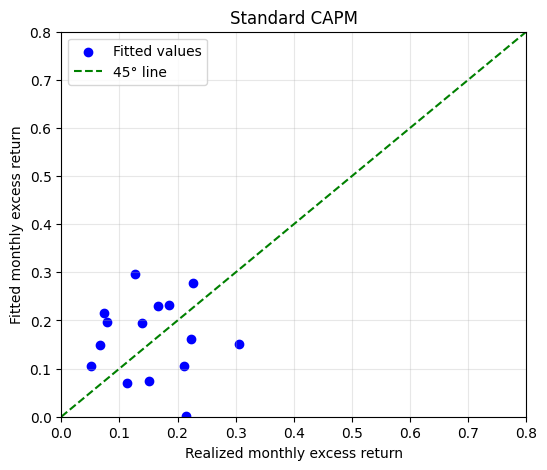

In [ ]:
def plot_fitted_vs_realized(true_vals, fitted_vals, title, range_tuple):
    plt.figure(figsize=(6, 5))
    plt.scatter(true_vals, fitted_vals, color='blue', label="Fitted values")
    plt.plot([range_tuple[0], range_tuple[1]], [range_tuple[0], range_tuple[1]], color='green', linestyle='--', label="45° line")
    plt.xlim(range_tuple[0], range_tuple[1])
    plt.ylim(range_tuple[0], range_tuple[1])
    plt.title(title)
    plt.xlabel("Realized monthly excess return")
    plt.ylabel("Fitted monthly excess return")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# Plot for CAPM
plot_fitted_vs_realized(100*E_rp_vec, 100*fitted_values_CAPM, "Standard CAPM", (0, 0.8))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     131.9
Date:                Wed, 25 Dec 2024   Prob (F-statistic):           8.78e-14
Time:                        23:00:20   Log-Likelihood:                 146.97
No. Observations:                  25   AIC:                            -285.9
Df Residuals:                      21   BIC:                            -281.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0044      0.001     -4.493      0.0

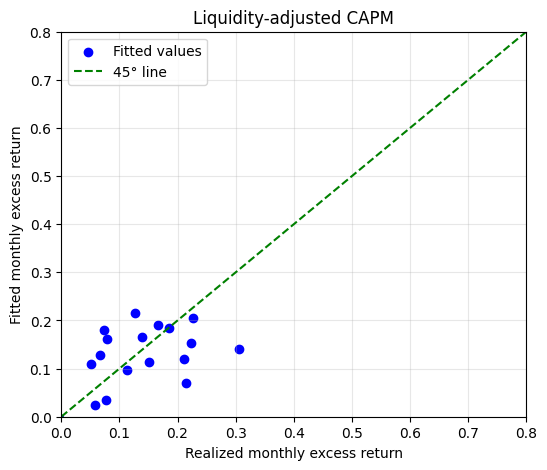

In [ ]:
# liquidity adjusted standard CAPM
# first model

y_vec = E_rp_vec
x1_vec = E_cp_vec
x2_vec = beta_1_arr.flatten()
x3_vec = beta_mat_net

# Creating a DataFrame
data_regression4 = pd.DataFrame({'x1': x1_vec, 'x2': x2_vec, 'x3': x3_vec, 'y': y_vec})
data_regression4['x1'] = pd.to_numeric(data_regression4['x1'], errors='coerce')
data_regression4['x2'] = pd.to_numeric(data_regression4['x2'], errors='coerce')
data_regression4['x3'] = pd.to_numeric(data_regression4['x3'], errors='coerce')
data_regression4['y'] = pd.to_numeric(data_regression4['y'], errors='coerce')
# Adding a constant for the intercept
X_4 = sm.add_constant(data_regression4[['x1', 'x2', 'x3']])  # Adds a column for b0 (the intercept)
y_4 = data_regression4['y']

# Fitting the model
model_4 = sm.OLS(y_4, X_4).fit()

# Printing the summary of the regression
print(model_4.summary())

# Predicted values
fitted_values_4 = model_4.predict(X_4)

plot_fitted_vs_realized(100*E_rp_vec, 100*fitted_values_4, "Liquidity-adjusted CAPM", (0, 0.8))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     76.29
Date:                Wed, 25 Dec 2024   Prob (F-statistic):           6.58e-12
Time:                        23:00:26   Log-Likelihood:                 147.73
No. Observations:                  25   AIC:                            -283.5
Df Residuals:                      19   BIC:                            -276.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0035      0.001     -2.574      0.0

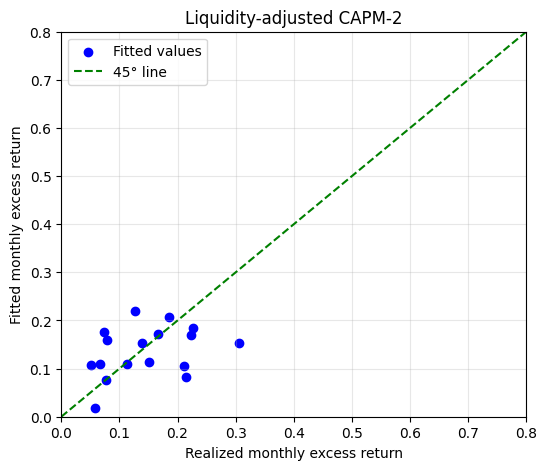

In [ ]:
# second model
y_vec = E_rp_vec
x1_vec = E_cp_vec
x2_vec = beta_1_arr.flatten()
x3_vec = beta_2_arr.flatten()
x4_vec = beta_3_arr.flatten()
x5_vec = beta_4_arr.flatten()

# Creating a DataFrame
data_regression5 = pd.DataFrame({'x1': x1_vec, 'x2': x2_vec, 'x3': x3_vec, 'x4': x4_vec, 'x5': x5_vec, 'y': y_vec})
data_regression5['x1'] = pd.to_numeric(data_regression5['x1'], errors='coerce')
data_regression5['x2'] = pd.to_numeric(data_regression5['x2'], errors='coerce')
data_regression5['x3'] = pd.to_numeric(data_regression5['x3'], errors='coerce')
data_regression5['x4'] = pd.to_numeric(data_regression5['x4'], errors='coerce')
data_regression5['x5'] = pd.to_numeric(data_regression5['x5'], errors='coerce')
data_regression5['y'] = pd.to_numeric(data_regression5['y'], errors='coerce')
# Adding a constant for the intercept
X_5 = sm.add_constant(data_regression5[['x1', 'x2', 'x3', 'x4', 'x5']]) 
y_5 = data_regression5['y']

# Fitting the model
model_5 = sm.OLS(y_5, X_5).fit()

# Printing the summary of the regression
print(model_5.summary())

# Predicted values
fitted_values_5 = model_5.predict(X_5)

plot_fitted_vs_realized(100*E_rp_vec, 100*fitted_values_5, "Liquidity-adjusted CAPM-2", (0, 0.8))

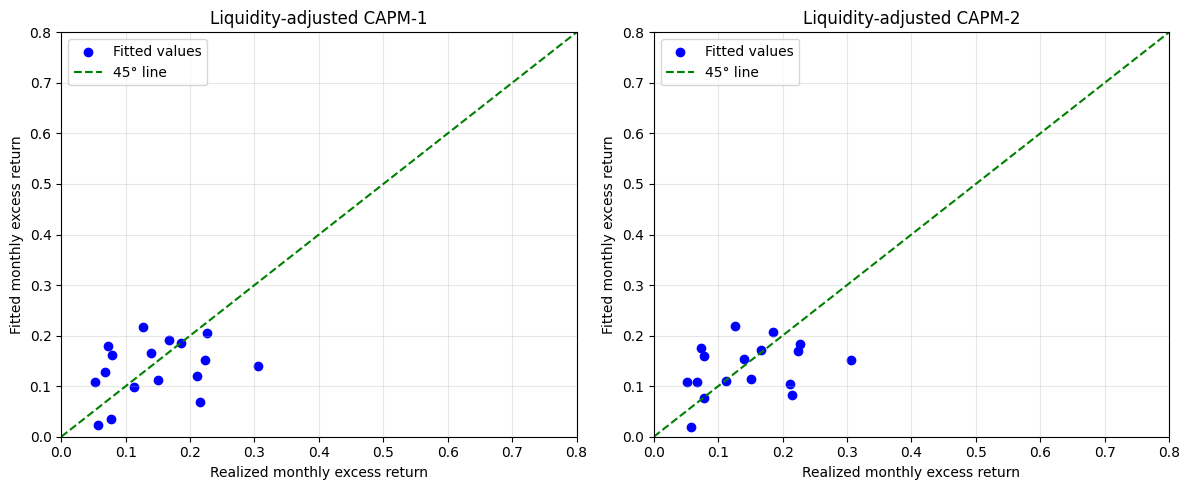

In [ ]:
def plot_fitted_vs_realized_subplots(true_vals1, fitted_vals1, title1, 
                                     true_vals2, fitted_vals2, title2, 
                                     range_tuple):
    plt.figure(figsize=(12, 5))  # Adjust width for two subplots

    # First subplot
    plt.subplot(1, 2, 1)
    plt.scatter(true_vals1, fitted_vals1, color='blue', label="Fitted values")
    plt.plot([range_tuple[0], range_tuple[1]], [range_tuple[0], range_tuple[1]], color='green', linestyle='--', label="45° line")
    plt.xlim(range_tuple[0], range_tuple[1])
    plt.ylim(range_tuple[0], range_tuple[1])
    plt.title(title1)
    plt.xlabel("Realized monthly excess return")
    plt.ylabel("Fitted monthly excess return")
    plt.grid(alpha=0.3)
    plt.legend()

    # Second subplot
    plt.subplot(1, 2, 2)
    plt.scatter(true_vals2, fitted_vals2, color='blue', label="Fitted values")
    plt.plot([range_tuple[0], range_tuple[1]], [range_tuple[0], range_tuple[1]], color='green', linestyle='--', label="45° line")
    plt.xlim(range_tuple[0], range_tuple[1])
    plt.ylim(range_tuple[0], range_tuple[1])
    plt.title(title2)
    plt.xlabel("Realized monthly excess return")
    plt.ylabel("Fitted monthly excess return")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_fitted_vs_realized_subplots(100*E_rp_vec, 100*fitted_values_4, "Liquidity-adjusted CAPM-1", 100*E_rp_vec, 100*fitted_values_5, "Liquidity-adjusted CAPM-2", (0, 0.8))